**Import core libraries**



In [ ]:
import pandas as pd
import numpy as np
import re
import unicodedata

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from textwrap import fill

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
sns.set_style("whitegrid")

**Install translation package**

In [ ]:
!pip install -q deep-translator
from deep_translator import GoogleTranslator

**Install translation package**

In [ ]:
df = pd.read_csv("/content/text classification and sentiment analysis.csv")
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
display(df.head(10))



Shape: (15283, 17)

Columns:
 ['Unnamed: 0', 'surveyID', 'surveyName', 'responseID', 'timestamp', 'location.country', 'operatingSystem', 'browser', 'language', 'timeTaken', 'responseStatus', 'emailAddress', 'questionCode', 'questionText', 'answerText', 'value.text', 'Batch_Date']


,Unnamed: 0,surveyID,surveyName,responseID,timestamp,location.country,operatingSystem,browser,language,timeTaken,responseStatus,emailAddress,questionCode,questionText,answerText,value.text,Batch_Date
0,4331,7814209,Defects Survey,142316144,2025-11-01 07:24:06,Malaysia,ANDROID1,CHROME_MOBILE,Chinese (Simplified),18,Started,puiyng1227@gmail.com,Q20,How satisfied are you with the customer support provided for the Novade application?,Satisfied,NaN,2026-02-28
1,4329,7814209,Defects Survey,142316144,2025-11-01 07:24:06,Malaysia,ANDROID1,CHROME_MOBILE,Chinese (Simplified),18,Started,puiyng1227@gmail.com,Q4,Wed like to ask you a few questions regarding the defect rectification process that you went through,NaN,NaN,2026-02-28
2,4328,7814209,Defects Survey,142316144,2025-11-01 07:24:06,Malaysia,ANDROID1,CHROME_MOBILE,Chinese (Simplified),18,Started,puiyng1227@gmail.com,Q3,Your defect rectification experience,NaN,NaN,2026-02-28
3,4327,7814209,Defects Survey,142316144,2025-11-01 07:24:06,Malaysia,ANDROID1,CHROME_MOBILE,Chinese (Simplified),18,Started,puiyng1227@gmail.com,Q1,How likely would you recommend Mah Sings product to a friend or colleague?,8,NaN,2026-02-28
4,4330,7814209,Defects Survey,142316144,2025-11-01 07:24:06,Malaysia,ANDROID1,CHROME_MOBILE,Chinese (Simplified),18,Started,puiyng1227@gmail.com,Q18,How easy is it to use the Novade application?,Easy,NaN,2026-02-28
5,4326,7814209,Defects Survey,142317923,2025-11-01 09:54:04,Malaysia,ANDROID1,CHROME_MOBILE,English,151,Completed,chua9639@yahoo.com,Q17,Would you like us to contact you for a follow-up discussion?,"Sure, feel free to contact me",NaN,2026-02-28
6,4325,7814209,Defects Survey,142317923,2025-11-01 09:54:04,Malaysia,ANDROID1,CHROME_MOBILE,English,151,Completed,chua9639@yahoo.com,Q16,Mobile Number For example +60191234567,NaN,+60192379762,2026-02-28
7,4324,7814209,Defects Survey,142317923,2025-11-01 09:54:04,Malaysia,ANDROID1,CHROME_MOBILE,English,151,Completed,chua9639@yahoo.com,Q15,Full Name (as per MyKad / Passport / Company Registration) For example: Lim Siew Sin,NaN,Chua Boon Chia,2026-02-28
8,4323,7814209,Defects Survey,142317923,2025-11-01 09:54:04,Malaysia,ANDROID1,CHROME_MOBILE,English,151,Completed,chua9639@yahoo.com,Q18,Property Purchased (A-Z List of Projects),"M Luna, Kepong",NaN,2026-02-28
9,4321,7814209,Defects Survey,142317923,2025-11-01 09:54:04,Malaysia,ANDROID1,CHROME_MOBILE,English,151,Completed,chua9639@yahoo.com,Q10,What can Mah Sing do to improve your satisfaction with our Customer Service Representatives?,NaN,NaN,2026-02-28


**Initial inspection**

**Shows data types, missing values, survey distribution, response status, and counts of unique IDs/questions.**

In [ ]:
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nSurvey distribution:")
print(df["surveyName"].value_counts(dropna=False))

print("\nResponse status distribution:")
print(df["responseStatus"].value_counts(dropna=False))

print("\nUnique responseIDs:", df["responseID"].nunique())
print("Unique questionCode:", df["questionCode"].nunique())
print("Unique questionText:", df["questionText"].nunique())


Data types:
Unnamed: 0           int64
surveyID             int64
surveyName          object
responseID           int64
timestamp           object
location.country    object
operatingSystem     object
browser             object
language            object
timeTaken            int64
responseStatus      object
emailAddress        object
questionCode        object
questionText        object
answerText          object
value.text          object
Batch_Date          object
dtype: object

Missing values:
value.text          13460
answerText           3550
location.country     1246
emailAddress           37
Unnamed: 0              0
timestamp               0
surveyID                0
responseID              0
surveyName              0
language                0
browser                 0
operatingSystem         0
timeTaken               0
questionCode            0
responseStatus          0
questionText            0
Batch_Date              0
dtype: int64

Survey distribution:
surveyName
18 Months

**Question understanding and merge validation**

**Unique questions list**

Extracts all unique questionText values.
Why used: To understand how many distinct survey questions exist.

In [ ]:
unique_questions = df["questionText"].drop_duplicates()

print("Total unique questions:", len(unique_questions))
unique_questions.head(62)

Total unique questions: 62


,questionText
0,How satisfied are you with the customer support provided for the Novade application?
1,Wed like to ask you a few questions regarding the defect rectification process that you went through
2,Your defect rectification experience
3,How likely would you recommend Mah Sings product to a friend or colleague?
4,How easy is it to use the Novade application?
...,...
984,What can Mah Sing do to improve your satisfaction with our M Privilege programme? (Multiple choices)
986,I feel appreciated by Mah Sing as an M Privilege member.
987,I would be keen on utilizing its benefits and rewards.
988,"I am aware of what M Privilege is, and the available benefits and rewards."



**Inspect Responses by Question**

Loops through each question and shows response-level data.
To understand how answers are stored for each question.

In [ ]:
for q in df["questionText"].unique():
    temp = df[df["questionText"] == q]

    print("\n" + "="*80)
    print("QUESTION:", q)
    print("Total Responses:", temp.shape[0])

    display(temp[[
        "responseID",
        "answerText",
        "value.text"
    ]].head(10))


QUESTION: How satisfied are you with the customer support provided for the Novade application? 
Total Responses: 226


,responseID,answerText,value.text
0,142316144,Satisfied,NaN
18,142317923,Satisfied,NaN
42,142317996,Satisfied,NaN
48,142319638,Satisfied,NaN
60,142320001,Satisfied,NaN
76,142320283,Satisfied,NaN
105,142322256,Neither satisfied nor dissatisfied,NaN
117,142323125,Satisfied,NaN
146,142323274,Extremely satisfied,NaN
159,142323441,Satisfied,NaN



QUESTION: Wed like to ask you a few questions regarding the defect rectification process that you went through
Total Responses: 243


,responseID,answerText,value.text
1,142316144,NaN,NaN
22,142317923,NaN,NaN
44,142317996,NaN,NaN
50,142319638,NaN,NaN
58,142320001,NaN,NaN
74,142320283,NaN,NaN
92,142322256,NaN,NaN
115,142323125,NaN,NaN
148,142323274,NaN,NaN
157,142323441,NaN,NaN



QUESTION: Your defect rectification experience
Total Responses: 243


...

,responseID,answerText,value.text
987,142481016,Disagree,NaN
1006,142482092,Agree,NaN
1057,142482417,Neither agree nor disagree,NaN
1095,142482424,Strongly agree,NaN
1131,142482426,Agree,NaN
1164,142482529,Disagree,NaN
1205,142482571,Strongly disagree,NaN
1241,142482617,Neither agree nor disagree,NaN
1281,142482664,Disagree,NaN
1327,142482688,Neither agree nor disagree,NaN



QUESTION: I am aware of what M Privilege is, and the available benefits and rewards.
Total Responses: 268


,responseID,answerText,value.text
988,142481016,Neither agree nor disagree,NaN
1005,142482092,Agree,NaN
1059,142482417,Neither agree nor disagree,NaN
1097,142482424,Strongly agree,NaN
1133,142482426,Agree,NaN
1166,142482529,Disagree,NaN
1189,142482571,Neither agree nor disagree,NaN
1228,142482617,Neither agree nor disagree,NaN
1279,142482664,Disagree,NaN
1317,142482688,Neither agree nor disagree,NaN



QUESTION: I did not use any of the property support services on M Concierge because: 
Total Responses: 211


,responseID,answerText,value.text
1008,142482092,I am not aware of these services,NaN
1052,142482417,I am not aware of these services,NaN
1092,142482424,I have my own service provider,NaN
1128,142482426,I am not aware of these services,NaN
1160,142482529,I have my own service provider,NaN
1200,142482571,The services offered do not meet my requirements,NaN
1239,142482617,I am not aware of these services,NaN
1278,142482664,The services offered do not meet my requirements,NaN
1319,142482688,I am not aware of these services,NaN
1365,142482851,I am not aware of these services,NaN


**Check Answer Storage Pattern**

Counts rows where only answerText, only value.text, both, or neither are present and To prove that answers are split across the two columns.

In [ ]:
print("Only answerText:", ((df["answerText"].notna()) & (df["value.text"].isna())).sum())
print("Only value.text:", ((df["answerText"].isna()) & (df["value.text"].notna())).sum())
print("Both present:", ((df["answerText"].notna()) & (df["value.text"].notna())).sum())
print("Both missing:", ((df["answerText"].isna()) & (df["value.text"].isna())).sum())

Only answerText: 11733
Only value.text: 1823
Both present: 0
Both missing: 1727


**Show examples from each answer source**

**Inspect value.text and answerText Examples**

Displays sample rows where the answer comes from only one of the two answer columns.
To verify the split-answer behavior visually.

In [ ]:
df[(df["answerText"].isna()) & (df["value.text"].notna())][
    ["questionText", "answerText", "value.text"]
].head(10)

,questionText,answerText,value.text
6,Mobile Number For example +60191234567,NaN,+60192379762
7,Full Name (as per MyKad / Passport / Company Registration) For example: Lim Siew Sin,NaN,Chua Boon Chia
37,What can Mah Sing do to improve your satisfaction with the defect rectifications?,NaN,很多间房屋的厕所漏水 多注意
64,What can Mah Sing do to improve your satisfaction with the defect rectifications?,NaN,Speed
88,Mobile Number For example +60191234567,NaN,0177467715
90,Full Name (as per MyKad / Passport / Company Registration) For example: Lim Siew Sin,NaN,Dheneshwaran Virasagaram
91,What can Mah Sing do to improve your satisfaction with our Customer Service Representatives?,NaN,聘请多点各种族的人 了解沟通比较容易
97,What can Mah Sing do to improve your satisfaction with the defect rectifications?,NaN,效率
104,What can Mah Sing do to improve your satisfaction with customer support for the Novade application?,NaN,上传照片的清晰度
128,Full Name (as per MyKad / Passport / Company Registration) For example: Lim Siew Sin,NaN,Soon Kean Seng


In [ ]:
df[(df["answerText"].notna()) & (df["value.text"].isna())][
    ["questionText", "answerText", "value.text"]
].head(10)

,questionText,answerText,value.text
0,How satisfied are you with the customer support provided for the Novade application?,Satisfied,NaN
3,How likely would you recommend Mah Sings product to a friend or colleague?,8,NaN
4,How easy is it to use the Novade application?,Easy,NaN
5,Would you like us to contact you for a follow-up discussion?,"Sure, feel free to contact me",NaN
8,Property Purchased (A-Z List of Projects),"M Luna, Kepong",NaN
10,The Customer Service Representative made me feel cared for,Agree,NaN
11,The Customer Service Representative was polite and friendly,Agree,NaN
12,The Customer Service Representative understood my defect rectification submission,Agree,NaN
13,The Customer Service Representative was consistently prompt in his/her response,Agree,NaN
15,The appointment date/time given to you,Satisfied,NaN


**Preview Raw Answer Examples**

To understand the kinds of responses present in both columns.

In [ ]:
print("answerText examples:")
print(df["answerText"].dropna().unique()[:10])

print("\nvalue.text examples:")
print(df["value.text"].dropna().unique()[:10])

answerText examples:
['Satisfied' '8' 'Easy' 'Sure, feel free to contact me' 'M Luna, Kepong'
 'Agree' 'Likely' '6' 'No, please dont contact me' 'Strongly agree']

value.text examples:
['+60192379762' 'Chua Boon Chia' '很多间房屋的厕所漏水 多注意 ' 'Speed' '0177467715'
 'Dheneshwaran Virasagaram' '聘请多点各种族的人 了解沟通比较容易' '效率' '上传照片的清晰度'
 'Soon Kean Seng ']


**Merge answer columns**

 Merge Answer Columns
Creates final_answer_raw using answerText first, otherwise value.text.
To create one unified answer column for all further processing.

In [ ]:
df["answerText"] = df["answerText"].replace({np.nan: None})
df["value.text"] = df["value.text"].replace({np.nan: None})

df["final_answer_raw"] = df["answerText"].combine_first(df["value.text"])

**Remove empty answers**

Remove Empty Responses
Drops rows where final_answer_raw is null or blank.
To keep only usable responses with actual content.

In [ ]:
df = df[df["final_answer_raw"].notna()]
df = df[df["final_answer_raw"].str.strip() != ""]

**Merged answer preview**

Preview Merged Answers
Shows questionText, answerText, value.text, and final_answer_raw.
To confirm the merge worked correctly.

In [ ]:

check_merge = df[[
    "responseID",
    "questionText",
    "answerText",
    "value.text",
    "final_answer_raw"
]].copy()

check_merge.head(10)

,responseID,questionText,answerText,value.text,final_answer_raw
0,142316144,How satisfied are you with the customer support provided for the Novade application?,Satisfied,None,Satisfied
3,142316144,How likely would you recommend Mah Sings product to a friend or colleague?,8,None,8
4,142316144,How easy is it to use the Novade application?,Easy,None,Easy
5,142317923,Would you like us to contact you for a follow-up discussion?,"Sure, feel free to contact me",None,"Sure, feel free to contact me"
6,142317923,Mobile Number For example +60191234567,None,+60192379762,+60192379762
7,142317923,Full Name (as per MyKad / Passport / Company Registration) For example: Lim Siew Sin,None,Chua Boon Chia,Chua Boon Chia
8,142317923,Property Purchased (A-Z List of Projects),"M Luna, Kepong",None,"M Luna, Kepong"
10,142317923,The Customer Service Representative made me feel cared for,Agree,None,Agree
11,142317923,The Customer Service Representative was polite and friendly,Agree,None,Agree
12,142317923,The Customer Service Representative understood my defect rectification submission,Agree,None,Agree


**Merge source flag**

Track Answer Source
Creates merge_source to mark whether the merged answer came from answerText or value.text.
To analyze where answers are coming from.

In [ ]:
for q in df["questionText"].unique():
    temp = df[df["questionText"] == q][[
        "responseID",
        "answerText",
        "value.text",
        "final_answer_raw"
    ]]

    print("\n" + "="*100)
    print("QUESTION:", q)

    display(temp.head(10))


QUESTION: How satisfied are you with the customer support provided for the Novade application? 


,responseID,answerText,value.text,final_answer_raw
0,142316144,Satisfied,None,Satisfied
18,142317923,Satisfied,None,Satisfied
42,142317996,Satisfied,None,Satisfied
48,142319638,Satisfied,None,Satisfied
60,142320001,Satisfied,None,Satisfied
76,142320283,Satisfied,None,Satisfied
105,142322256,Neither satisfied nor dissatisfied,None,Neither satisfied nor dissatisfied
117,142323125,Satisfied,None,Satisfied
146,142323274,Extremely satisfied,None,Extremely satisfied
159,142323441,Satisfied,None,Satisfied



QUESTION: How likely would you recommend Mah Sings product to a friend or colleague?


,responseID,answerText,value.text,final_answer_raw
3,142316144,8,None,8
20,142317923,6,None,6
38,142317996,6,None,6
52,142319638,10,None,10
56,142320001,8,None,8
79,142320283,9,None,9
111,142322256,3,None,3
113,142323125,5,None,5
150,142323274,10,None,10
155,142323441,9,None,9



QUESTION: How easy is it to use the Novade application? 


...

,responseID,answerText,value.text,final_answer_raw
987,142481016,Disagree,None,Disagree
1006,142482092,Agree,None,Agree
1057,142482417,Neither agree nor disagree,None,Neither agree nor disagree
1095,142482424,Strongly agree,None,Strongly agree
1131,142482426,Agree,None,Agree
1164,142482529,Disagree,None,Disagree
1205,142482571,Strongly disagree,None,Strongly disagree
1241,142482617,Neither agree nor disagree,None,Neither agree nor disagree
1281,142482664,Disagree,None,Disagree
1327,142482688,Neither agree nor disagree,None,Neither agree nor disagree



QUESTION: I am aware of what M Privilege is, and the available benefits and rewards.


,responseID,answerText,value.text,final_answer_raw
988,142481016,Neither agree nor disagree,None,Neither agree nor disagree
1005,142482092,Agree,None,Agree
1059,142482417,Neither agree nor disagree,None,Neither agree nor disagree
1097,142482424,Strongly agree,None,Strongly agree
1133,142482426,Agree,None,Agree
1166,142482529,Disagree,None,Disagree
1189,142482571,Neither agree nor disagree,None,Neither agree nor disagree
1228,142482617,Neither agree nor disagree,None,Neither agree nor disagree
1279,142482664,Disagree,None,Disagree
1317,142482688,Neither agree nor disagree,None,Neither agree nor disagree



QUESTION: I did not use any of the property support services on M Concierge because: 


,responseID,answerText,value.text,final_answer_raw
1008,142482092,I am not aware of these services,None,I am not aware of these services
1052,142482417,I am not aware of these services,None,I am not aware of these services
1092,142482424,I have my own service provider,None,I have my own service provider
1128,142482426,I am not aware of these services,None,I am not aware of these services
1160,142482529,I have my own service provider,None,I have my own service provider
1200,142482571,The services offered do not meet my requirements,None,The services offered do not meet my requirements
1239,142482617,I am not aware of these services,None,I am not aware of these services
1278,142482664,The services offered do not meet my requirements,None,The services offered do not meet my requirements
1319,142482688,I am not aware of these services,None,I am not aware of these services
1365,142482851,I am not aware of these services,None,I am not aware of these services


**Merge source flag**

Track Answer Source creates merge_source to mark whether the merged answer came from answerText or value.text.
To analyze where answers are coming from.

In [ ]:
df["merge_source"] = np.where(
    df["answerText"].notna(),
    "answerText",
    "value.text"
)

df[["answerText", "value.text", "final_answer_raw", "merge_source"]].head(10)

,answerText,value.text,final_answer_raw,merge_source
0,Satisfied,None,Satisfied,answerText
3,8,None,8,answerText
4,Easy,None,Easy,answerText
5,"Sure, feel free to contact me",None,"Sure, feel free to contact me",answerText
6,None,+60192379762,+60192379762,value.text
7,None,Chua Boon Chia,Chua Boon Chia,value.text
8,"M Luna, Kepong",None,"M Luna, Kepong",answerText
10,Agree,None,Agree,answerText
11,Agree,None,Agree,answerText
12,Agree,None,Agree,answerText


In [ ]:
check_correct = (
    (df["final_answer_raw"] == df["answerText"]) |
    (df["final_answer_raw"] == df["value.text"])
)

print("Correct merge %:", check_correct.mean() * 100)

Correct merge %: 100.0


**Noise question exploration**

 Explore Potential Noise Questions
Searches for question texts containing things like full name, mobile number, etc.
To identify irrelevant survey fields before dropping them.

In [ ]:
noise_keywords = [
    "full name",
    "mobile number",
    "contact you",
    "property purchased",
    "passport",
    "company registration"
]

for k in noise_keywords:
    print(f"\nChecking keyword: '{k}'")
    display(df[df["questionText"].str.lower().str.contains(k, na=False)][
        ["questionText"]
    ].drop_duplicates())


Checking keyword: 'full name'


,questionText
7,Full Name (as per MyKad / Passport / Company Registration) For example: Lim Siew Sin



Checking keyword: 'mobile number'


,questionText
6,Mobile Number For example +60191234567



Checking keyword: 'contact you'


...

,questionText
8,Property Purchased (A-Z List of Projects)



Checking keyword: 'passport'


,questionText
7,Full Name (as per MyKad / Passport / Company Registration) For example: Lim Siew Sin



Checking keyword: 'company registration'


,questionText
7,Full Name (as per MyKad / Passport / Company Registration) For example: Lim Siew Sin


In [ ]:
df["questionText"].drop_duplicates().sort_values().head(50)

,questionText
959,Attentiveness in attending to any queries & providing assistance
956,Billings and payment
960,Cleanliness of common area
958,Maintenance of the facilities
957,Maintenance of the landscape
953,Professionalism of our security personnel
951,Registration of visitors and contractors before entering the compound
952,Security personnel are visibly presence.
970,What can Mah Sing do to improve your satisfaction with the security services?
954,What can Mah Sing do to improve your satisfaction with the services provided by Property Management?


In [ ]:
def is_noise_question(q):
    q = str(q).lower()

    noise_patterns = [
        "name",
        "mobile",
        "phone",
        "contact",
        "email"
    ]

    return any(p in q for p in noise_patterns)

# First check what will be removed
noise_df = df[df["questionText"].apply(is_noise_question)]

print("Noise questions detected:")
display(noise_df["questionText"].drop_duplicates())

# Then drop
df = df[~df["questionText"].apply(is_noise_question)].copy()

print("Shape after removal:", df.shape)

Noise questions detected:


,questionText
5,Would you like us to contact you for a follow-up discussion?
6,Mobile Number For example +60191234567
7,Full Name (as per MyKad / Passport / Company Registration) For example: Lim Siew Sin


Shape after removal: (12096, 19)


In [ ]:
def is_noise_question(q):
    q = str(q).lower()
    noise_keywords = [
        "full name",
        "mobile number",
        "contact you",
        "property purchased",
        "passport",
        "company registration"
    ]
    return any(k in q for k in noise_keywords)

df = df[~df["questionText"].apply(is_noise_question)].copy()

print("Shape after removing noise questions:", df.shape)

Shape after removing noise questions: (11651, 19)


**Diagnose Missing Final Answers**

Counts remaining nulls and inspects rows with missing final answers.
To understand which unanswered rows are being removed and why.

In [ ]:
df["final_answer_raw"].isnull().sum()

np.int64(0)

In [ ]:
df[df["final_answer_raw"].isna()][
    ["questionText", "answerText", "value.text"]
].head(10)

,questionText,answerText,value.text


In [ ]:
df = df[df["final_answer_raw"].notna()]
df = df[df["final_answer_raw"].str.strip() != ""]

In [ ]:
print("Remaining rows:", df.shape)
print("Missing answers:", df["final_answer_raw"].isnull().sum())

Remaining rows: (11651, 19)
Missing answers: 0


In [ ]:
df["final_answer_raw"].head(10)

,final_answer_raw
0,Satisfied
3,8
4,Easy
10,Agree
11,Agree
12,Agree
13,Agree
15,Satisfied
16,Satisfied
17,Likely


**Create safe question key**

Create Unique Question Key
Combines survey name, question code, and question text into question_key.
Because questionCode alone is not always unique.

In [ ]:
df["question_key"] = (
    df["surveyName"].astype(str) + " || " +
    df["questionCode"].astype(str) + " || " +
    df["questionText"].astype(str)
)

**Count unique question keys**

 Count Unique Question Keys. Shows how many unique combined question identifiers exist.
To confirm uniqueness after combining survey, code, and text.

In [ ]:
print("Unique question_key:", df["question_key"].nunique())

Unique question_key: 56


**Reused question code mapping**

Check Question Code Reuse
Finds cases where the same question code maps to multiple question texts.
To prove why question_key is safer than questionCode.

In [ ]:
code_map = (
    df.groupby(["surveyName", "questionCode"])["questionText"]
      .nunique()
      .reset_index(name="n_questionText")
      .sort_values(["n_questionText", "surveyName", "questionCode"], ascending=[False, True, True])
)

display(code_map[code_map["n_questionText"] > 1])

,surveyName,questionCode,n_questionText



**Remove Irrelevant Questions**

Defines noise patterns, removes noise rows, and checks remaining rows and top question frequencies.
To remove personal-information and non-sentiment fields from the dataset.

In [ ]:
remove_patterns = [
    "full name",
    "mobile number",
    "contact",
    "property",
    "would you like us to contact you"
]

df = df[~df["questionText"].str.lower().str.contains("|".join(remove_patterns), na=False)]

**Compute Answer Length**

Calculates the number of words in each answer.
To distinguish structured responses from open-text feedback.

In [ ]:
print("Remaining rows after noise removal:", df.shape)

Remaining rows after noise removal: (10971, 20)


In [ ]:
df["questionText"].value_counts().head(20)

,count
questionText,
What can Mah Sing do to improve your satisfaction with our M Privilege programme? (Multiple choices),401
How likely would you recommend Mah Sings product to a friend or colleague?,345
How likely would you recommend Mah Sing’s product to a friend or colleague?,335
The Customer Service Representative responded to my queries promptly.,317
The Customer Service Representative was polite and friendly.,317
Quality & workmanship,294
Location accessibility,294
Product design,294
Facilities,294


In [ ]:
df["answer_length"] = df["final_answer_raw"].apply(lambda x: len(str(x).split()))

df["answer_length"].describe()

,answer_length
count,10971.000000
mean,2.740680
std,6.602845
min,1.000000
25%,1.000000
50%,1.000000
75%,4.000000
max,212.000000


In [ ]:
df["is_numeric"] = df["final_answer_raw"].str.isdigit()

print(df["is_numeric"].value_counts())

is_numeric
False    10291
True       680
Name: count, dtype: int64


**Detect Numeric Responses**

 Creates is_numeric for responses like ratings.
To separate rating-style answers from text answers.

In [ ]:
df["final_answer_raw"].value_counts().head(20)

,count
final_answer_raw,
Satisfied,2704
Neither satisfied nor dissatisfied,1183
Agree,1174
Extremely satisfied,1007
Neither agree nor disagree,624
Strongly agree,449
Dissatisfied,358
Yes,243
Extremely dissatisfied,204


**Filter Meaningful Answers**

In [ ]:
df[df["answer_length"] > 5][["questionText", "final_answer_raw"]].head(10)

,questionText,final_answer_raw
129,What can Mah Sing do to improve your satisfaction with the defect rectifications?,Contractor shall ensure the defects are fully solve
204,What can Mah Sing do to improve your satisfaction with our Customer Service Representatives?,Customer service office should be open early.
213,What can Mah Sing do to improve your satisfaction with customer support for the Novade application?,Allowed customer to submit report without using apps. Defect major defect should be check by your team before give the key.
214,What can Mah Sing do to improve your satisfaction with the defect rectifications?,Improve the quality first before think about the repairing
334,What can Mah Sing do to improve your satisfaction with customer support for the Novade application?,"Make sure workmanship meet top tier standards. The workmanship is horrible. Even after submitting some issues, issues are marked completed/resolved but pictures show the workmanship is still very ..."
343,What can Mah Sing do to improve your satisfaction with the defect rectifications?,Uphold a certain standard/quality of workmanship so there arent this many defects in the first place.
377,What can Mah Sing do to improve your satisfaction with customer support for the Novade application?,"improve quality of work to reduce defect and improve the time taken to solve defect issues, it take around 3 months to solve my defect meanwhile i still need to pay for the mortgage."
384,What can Mah Sing do to improve your satisfaction with the defect rectifications?,add manpower and speed up the process
417,What can Mah Sing do to improve your satisfaction with customer support for the Novade application?,Benarkan seberapa banyak laporan kerosakan atau baikpulih supaya tindakan cepat diambil
436,"Overall, which area would you like to see Mah Sing improve on?","Masa yang dijanjikan untuk refund adalah 14 hari bekerja, tetapi saya menerima refund selepas 3 bulan+. Sila percepatkan lagi proses refund."


**Count responses per question and identify least frequent questions**

In [ ]:
df.groupby("questionText").size().sort_values().head(10)

,0
questionText,
What can Mah Sing do to improve your satisfaction with our M Concierge programme?,13
"Overall, which area would you like to see Mah Sing improve on?",20
I find the offered services are highly useful and relevant to my needs.,52
What can Mah Sing do to improve your satisfaction with our MY Mah Sing app?,66
What can Mah Sing do to improve your satisfaction with customer support for the Novade application?,73
What can Mah Sing do to improve your satisfaction with our Customer Service Representatives?,75
How satisfied were you with the timeliness of refund?,96
Please rate your overall experience with Mah Sing when handling your refund.,96
The Customer Service provided by Mah Sing during the refund process was helpful.,96


**Count didderent surveys** **in which survey how many value_text and answer_text are present**

In [ ]:
df["answer_source"] = np.where(
    df["answerText"].notna(), "answerText",
    np.where(df["value.text"].notna(), "value.text", "missing")
)

df.groupby(["surveyName", "answer_source"]).size()

surveyName                answer_source
18 Months Post VP Survey  answerText       7327
                          value.text        427
Defects Survey            answerText       2526
                          value.text        281
Refund Survey             answerText        390
                          value.text         20
dtype: int64

**Categorizes questions into specific intent types like NPS, satisfaction, ease, agreement, or feedback**

In [ ]:
def question_family(q):
    q = str(q).lower()

    if "recommend" in q:
        return "nps"
    elif "satisfied" in q:
        return "satisfaction"
    elif "easy" in q:
        return "ease"
    elif "agree" in q or "polite" in q or "friendly" in q:
        return "agreement"
    elif "improve" in q or "comment" in q:
        return "feedback"
    else:
        return "other"

**Counts groups questions into rating intent, structured sentiment, or open feedback categories**

In [ ]:
def question_group(q):
    q = str(q).lower()

    if "recommend" in q or "likely" in q:
        return "rating_intent"
    elif "satisfied" in q or "easy" in q or "agree" in q:
        return "structured_sentiment"
    elif "improve" in q or "comment" in q or "suggest" in q:
        return "open_feedback"
    else:
        return "other"

df["question_group"] = df["questionText"].apply(question_group)

print(df["question_group"].value_counts())

question_group
other                   7911
rating_intent           1139
open_feedback           1129
structured_sentiment     792
Name: count, dtype: int64


**Identify open-text responses and classify questions into categories to understand response types and distribution across different question intents.**

In [ ]:
fixed_values = [
    "satisfied", "agree", "easy", "yes", "no"
]

df["answer_lower"] = df["final_answer_raw"].str.lower().str.strip()

df["is_open_text"] = (
    (df["answer_length"] > 3) &
    (~df["answer_lower"].isin(fixed_values)) &
    (~df["is_numeric"])
)

In [ ]:
df["question_family"] = df["questionText"].apply(question_family)
df["question_family"].value_counts()

,count
question_family,
other,7853
feedback,1129
nps,680
agreement,517
ease,470
satisfaction,322


**Clean and standardize text by removing extra spaces, special characters, and normalizing Unicode**

In [ ]:
import re
import unicodedata

def normalize_text(x):
    if pd.isna(x):
        return x

    x = str(x)
    x = unicodedata.normalize("NFKC", x)
    x = x.replace("\u00a0", " ")
    x = re.sub(r"\s+", " ", x).strip()

    return x

**Generate cleaned and lowercase versions of question and answer text for consistency**

In [ ]:
df["questionText_clean"] = df["questionText"].apply(normalize_text)
df["final_answer_clean"] = df["final_answer_raw"].apply(normalize_text)

df["questionText_lower"] = df["questionText_clean"].str.lower()
df["final_answer_lower"] = df["final_answer_clean"].str.lower()

**Testing different languages**

In [ ]:
df["language_clean"] = df["language"].astype(str).str.lower().str.strip()

print(df["language_clean"].value_counts())

language_clean
english                 7595
malay                   2552
chinese (simplified)     824
Name: count, dtype: int64


**Standardize varied response texts into consistent predefined labels while preserving original text for unmapped values**

In [ ]:
label_map = {
    "very easy": "Very easy",
    "easy": "Easy",
    "neither easy nor difficult": "Neither easy nor difficult",
    "difficult": "Difficult",
    "very difficult": "Very difficult",

    "extremely satisfied": "Extremely satisfied",
    "satisfied": "Satisfied",
    "neither satisfied nor dissatisfied": "Neither satisfied nor dissatisfied",
    "dissatisfied": "Dissatisfied",
    "extremely dissatisfied": "Extremely dissatisfied",

    "strongly agree": "Strongly agree",
    "agree": "Agree",
    "neither agree nor disagree": "Neither agree nor disagree",
    "disagree": "Disagree",
    "strongly disagree": "Strongly disagree",

    "very positive": "Very positive",
    "positive": "Positive",
    "neither positive nor negative": "Neither positive nor negative",
    "negative": "Negative",
    "very negative": "Very negative",

    "very likely": "Very likely",
    "likely": "Likely",
    "neither likely nor unlikely": "Neither likely nor unlikely",
    "unlikely": "Unlikely",
    "very unlikely": "Very unlikely",

    "yes": "Yes",
    "no": "No"
}

df["final_answer_norm"] = df["final_answer_lower"].map(label_map).fillna(df["final_answer_clean"])

**Rows By Survey**

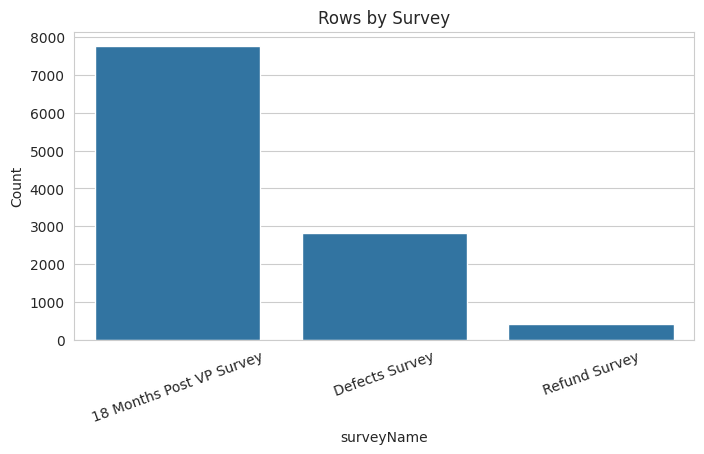

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
survey_counts = df["surveyName"].value_counts()
sns.barplot(x=survey_counts.index, y=survey_counts.values)
plt.title("Rows by Survey")
plt.xticks(rotation=20)
plt.ylabel("Count")
plt.show()

**Answer_text vs Value_text**

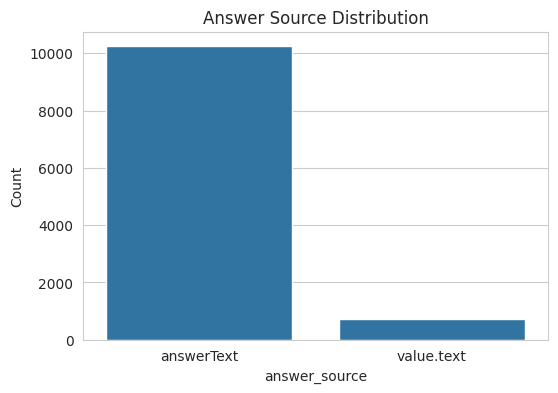

In [ ]:
plt.figure(figsize=(6,4))
src_counts = df["answer_source"].value_counts()
sns.barplot(x=src_counts.index, y=src_counts.values)
plt.title("Answer Source Distribution")
plt.ylabel("Count")
plt.show()

**Numeric vs Non-Numeric Answer**

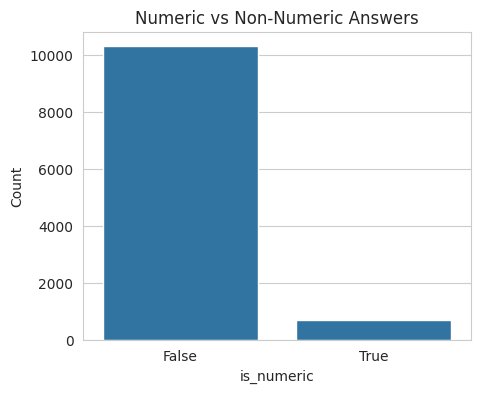

In [ ]:
plt.figure(figsize=(5,4))
num_counts = df["is_numeric"].value_counts()
sns.barplot(x=num_counts.index.astype(str), y=num_counts.values)
plt.title("Numeric vs Non-Numeric Answers")
plt.xlabel("is_numeric")
plt.ylabel("Count")
plt.show()


**Identify open-text responses by excluding predefined structured answers and numeric values, enabling separation of free-text feedback from fixed survey responses**

In [ ]:
fixed_values = {
    "extremely satisfied", "satisfied", "neither satisfied nor dissatisfied", "dissatisfied", "extremely dissatisfied",
    "strongly agree", "agree", "neither agree nor disagree", "disagree", "strongly disagree",
    "very easy", "easy", "neither easy nor difficult", "difficult", "very difficult",
    "very positive", "positive", "neither positive nor negative", "negative", "very negative",
    "very likely", "likely", "neither likely nor unlikely", "unlikely", "very unlikely",
    "yes", "no", "sure, feel free to contact me", "no, please dont contact me"
}

df["answer_lower"] = df["final_answer_norm"].astype(str).str.lower().str.strip()

df["is_open_text"] = (
    ((df["answer_source"] == "value.text") | (df["answer_length"] > 3)) &
    (~df["answer_lower"].isin(fixed_values)) &
    (~df["is_numeric"])
)

print(df["is_open_text"].value_counts())

is_open_text
False    9856
True     1115
Name: count, dtype: int64


**Translated all the other languages to English**

In [ ]:
def translate_text(text):
    try:
        return GoogleTranslator(source='auto', target='en').translate(str(text))
    except:
        return text

In [ ]:
df["translated_answer"] = df["final_answer_clean"]

open_mask = df["is_open_text"] == True

df.loc[open_mask, "translated_answer"] = df.loc[open_mask, "final_answer_clean"].apply(translate_text)

print(df[["final_answer_clean", "translated_answer"]].head(10))

   final_answer_clean translated_answer
0           Satisfied         Satisfied
3                   8                 8
4                Easy              Easy
10              Agree             Agree
11              Agree             Agree
12              Agree             Agree
13              Agree             Agree
15          Satisfied         Satisfied
16          Satisfied         Satisfied
17             Likely            Likely


**Translated Answers**

In [ ]:
df[df["is_open_text"] == True][
    ["final_answer_clean", "translated_answer"]
].head(20)

,final_answer_clean,translated_answer
37,很多间房屋的厕所漏水 多注意,"Toilets in many houses are leaking, please pay attention"
64,Speed,Speed
91,聘请多点各种族的人 了解沟通比较容易,Hire more people of various races to understand and communicate more easily
97,效率,efficiency
104,上传照片的清晰度,Upload photo clarity
129,Contractor shall ensure the defects are fully solve,Contractor shall ensure the defects are fully solve
204,Customer service office should be open early.,Customer service office should be open early.
213,Allowed customer to submit report without using apps. Defect major defect should be check by your team before give the key.,Allowed customer to submit report without using apps. Defect major defect should be check by your team before give the key.
214,Improve the quality first before think about the repairing,Improve the quality first before think about the repairing
226,Visibility on major defect,Visibility on major defect


In [ ]:
df[
    (df["is_open_text"] == True) &
    (df["language_clean"] != "english")
][["language_clean", "final_answer_clean", "translated_answer"]].head(20)

,language_clean,final_answer_clean,translated_answer
37,chinese (simplified),很多间房屋的厕所漏水 多注意,"Toilets in many houses are leaking, please pay attention"
91,chinese (simplified),聘请多点各种族的人 了解沟通比较容易,Hire more people of various races to understand and communicate more easily
97,chinese (simplified),效率,efficiency
104,chinese (simplified),上传照片的清晰度,Upload photo clarity
417,malay,Benarkan seberapa banyak laporan kerosakan atau baikpulih supaya tindakan cepat diambil,Allow as many damage or repair reports as possible so that quick action is taken
424,malay,Cepat bertindak,Act quickly
429,malay,tiada,none
436,malay,"Masa yang dijanjikan untuk refund adalah 14 hari bekerja, tetapi saya menerima refund selepas 3 bulan+. Sila percepatkan lagi proses refund.","The promised time for a refund is 14 working days, but I received a refund after 3 months+. Please speed up the refund process."
454,chinese (simplified),"安排多点人手,时间管理再好一些在短时间内解决缺陷。在答应的时间内完成",Arrange more manpower and better time management to solve defects in a short time. Complete within the promised time
462,chinese (simplified),提高缺陷修复的效率和质量,Improve efficiency and quality of defect repair


**Texts which are chinese**

In [ ]:
df[
    (df["is_open_text"] == True) &
    (df["language_clean"] == "chinese")
][["final_answer_clean", "translated_answer"]].head(20)

,final_answer_clean,translated_answer


**Texts which are malaysian**

In [ ]:
df[
    (df["is_open_text"] == True) &
    (df["language_clean"] == "malay")
][["final_answer_clean", "translated_answer"]].head(20)

,final_answer_clean,translated_answer
417,Benarkan seberapa banyak laporan kerosakan atau baikpulih supaya tindakan cepat diambil,Allow as many damage or repair reports as possible so that quick action is taken
424,Cepat bertindak,Act quickly
429,tiada,none
436,"Masa yang dijanjikan untuk refund adalah 14 hari bekerja, tetapi saya menerima refund selepas 3 bulan+. Sila percepatkan lagi proses refund.","The promised time for a refund is 14 working days, but I received a refund after 3 months+. Please speed up the refund process."
489,Tempoh masa pbaikan dipercepatkn lagi,The repair period is accelerated again
653,Saya tak boleh rate untuk temu janji kerana saya tidak melakukan peemriksaan bersama,I can't rate for dating because I didn't do the inspection together
694,tiada fungsi bulk upload. tiada fungsi untuk download report. koordinasi team defect dan apps Novade tidak selari.,no bulk upload function. There is no function to download the report. defect team coordination and Novade apps are not parallel.
696,"setiap team defect datang rumah, pastikan ada SV untuk pantau kerja mereka","every defect team comes home, make sure there is an SV to monitor their work"
701,"team khidmat pelanggan mesti sentiasa dapatkan maklumat dari team projek. jgn nak ping pong, oh ini team projek saja tahu, jadi isunya tergantung.","The customer service team must always get information from the project team. Don't want to play ping pong, oh this is only the project team knows, so the issue depends."
855,Area mne ade,Area mne ade


**Translation % which decides which much translation happens**

In [ ]:
total_open = df[df["is_open_text"] == True].shape[0]
changed_rows = df[df["final_answer_clean"] != df["translated_answer"]].shape[0]

print("Translation %:", (changed_rows / total_open) * 100)

Translation %: 23.58744394618834


In [ ]:
df["final_answer_for_model"] = np.where(
    df["is_open_text"] == True,
    df["translated_answer"],
    df["final_answer_norm"]
)

df[["final_answer_clean", "translated_answer", "final_answer_for_model"]].head(10)

,final_answer_clean,translated_answer,final_answer_for_model
0,Satisfied,Satisfied,Satisfied
3,8,8,8
4,Easy,Easy,Easy
10,Agree,Agree,Agree
11,Agree,Agree,Agree
12,Agree,Agree,Agree
13,Agree,Agree,Agree
15,Satisfied,Satisfied,Satisfied
16,Satisfied,Satisfied,Satisfied
17,Likely,Likely,Likely


**After translation final dataset shape**

In [ ]:
final_df = df[[
    "responseID",
    "surveyName",
    "language_clean",
    "question_group",
    "question_family",
    "questionText_clean",
    "final_answer_clean",
    "translated_answer",
    "final_answer_for_model",
    "is_open_text"
]].copy()

print("Final dataset shape:", final_df.shape)
final_df.head()

Final dataset shape: (10971, 10)


,responseID,surveyName,language_clean,question_group,question_family,questionText_clean,final_answer_clean,translated_answer,final_answer_for_model,is_open_text
0,142316144,Defects Survey,chinese (simplified),structured_sentiment,satisfaction,How satisfied are you with the customer support provided for the Novade application?,Satisfied,Satisfied,Satisfied,False
3,142316144,Defects Survey,chinese (simplified),rating_intent,nps,How likely would you recommend Mah Sings product to a friend or colleague?,8,8,8,False
4,142316144,Defects Survey,chinese (simplified),structured_sentiment,ease,How easy is it to use the Novade application?,Easy,Easy,Easy,False
10,142317923,Defects Survey,english,other,other,The Customer Service Representative made me feel cared for,Agree,Agree,Agree,False
11,142317923,Defects Survey,english,other,agreement,The Customer Service Representative was polite and friendly,Agree,Agree,Agree,False


**Open-text vs Structured Answers**

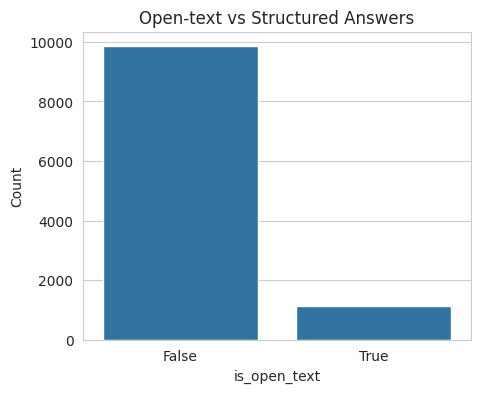

In [ ]:
plt.figure(figsize=(5,4))
open_counts = df["is_open_text"].value_counts()
sns.barplot(x=open_counts.index.astype(str), y=open_counts.values)
plt.title("Open-text vs Structured Answers")
plt.xlabel("is_open_text")
plt.ylabel("Count")
plt.show()

**How many types of sentiment keywords present in questions and their distribution **

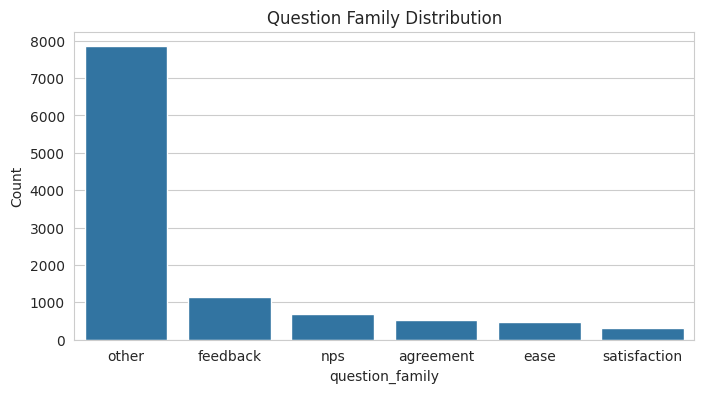

In [ ]:
plt.figure(figsize=(8,4))
fam_counts = df["question_family"].value_counts()
sns.barplot(x=fam_counts.index, y=fam_counts.values)
plt.title("Question Family Distribution")
plt.ylabel("Count")
plt.show()

**Top Structured Answer Values**

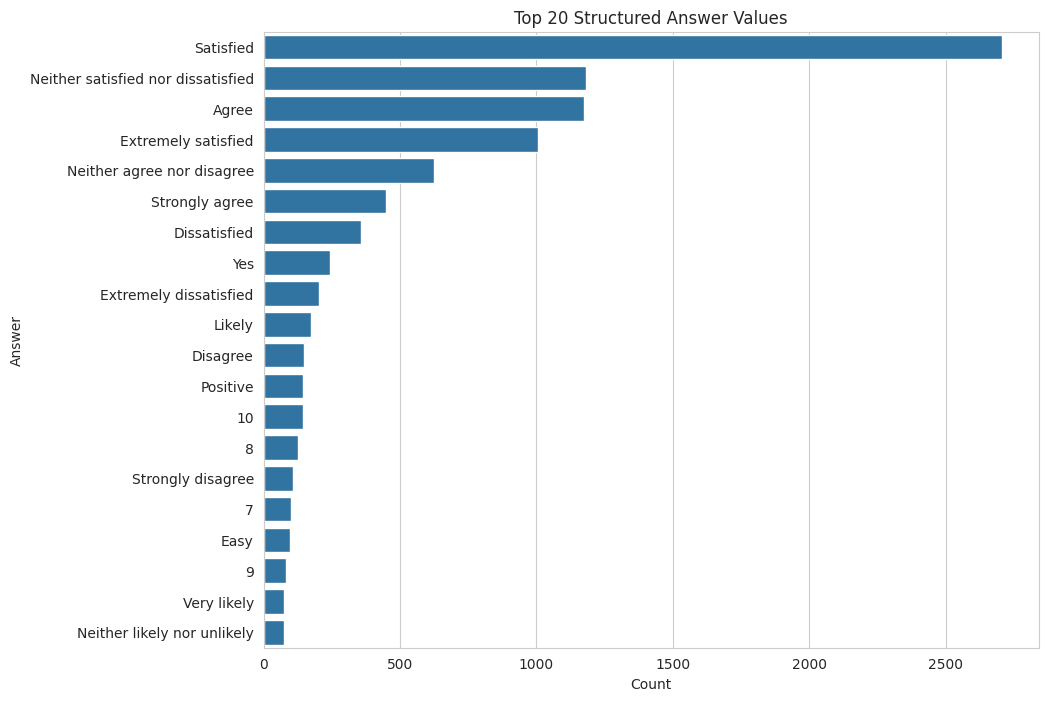

In [ ]:
structured_df = df[~df["is_open_text"]].copy()
top_structured = structured_df["final_answer_norm"].value_counts().head(20)

plt.figure(figsize=(10,8))
sns.barplot(x=top_structured.values, y=top_structured.index)
plt.title("Top 20 Structured Answer Values")
plt.xlabel("Count")
plt.ylabel("Answer")
plt.show()

**Top Open- Text Questions**

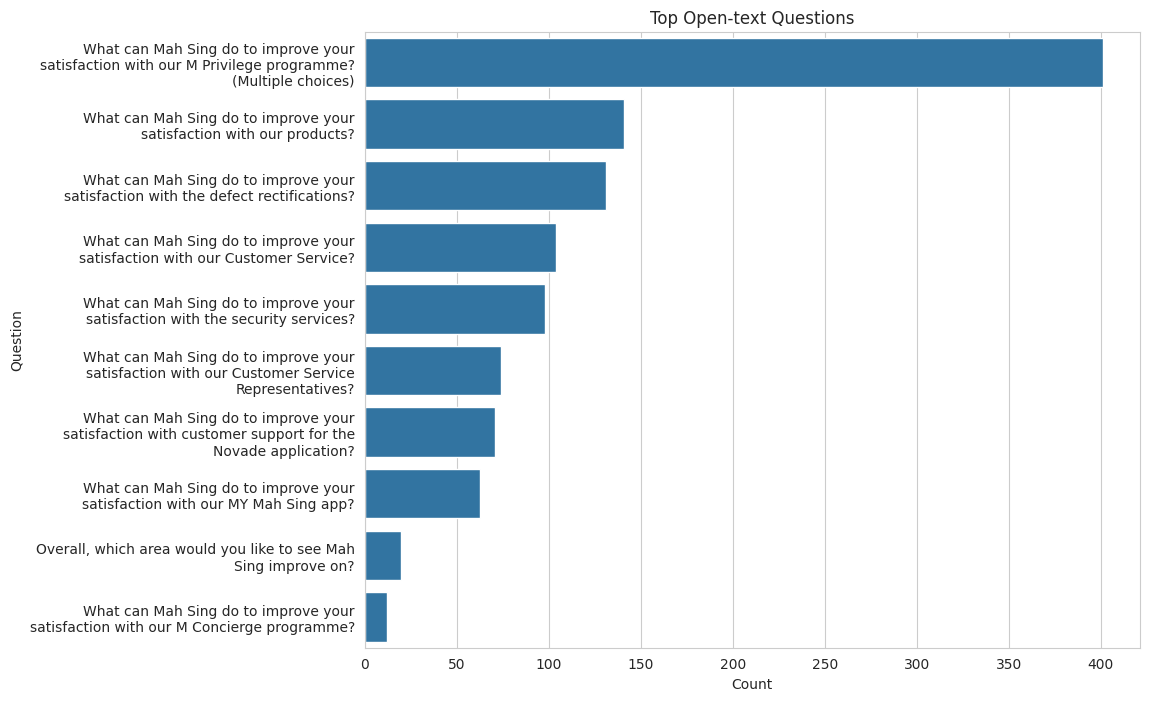

In [ ]:
from textwrap import fill

open_q = (
    df[df["is_open_text"]]["questionText_clean"]
    .value_counts()
    .head(15)
    .reset_index()
)
open_q.columns = ["questionText_clean", "count"]
open_q["questionText_short"] = open_q["questionText_clean"].apply(lambda x: fill(x, width=45))

plt.figure(figsize=(10,8))
sns.barplot(data=open_q, x="count", y="questionText_short")
plt.title("Top Open-text Questions")
plt.xlabel("Count")
plt.ylabel("Question")
plt.show()

**Distribution of Numeric Answers like Rating**

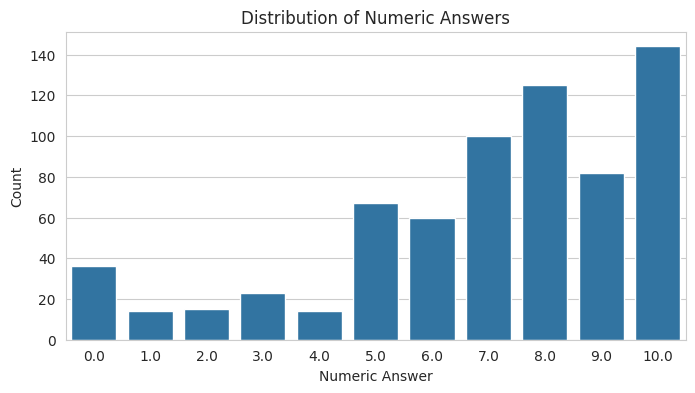

In [ ]:
df["numeric_answer"] = pd.to_numeric(df["final_answer_clean"], errors="coerce")
num_df = df[df["numeric_answer"].notna()].copy()

plt.figure(figsize=(8,4))
sns.countplot(data=num_df, x="numeric_answer")
plt.title("Distribution of Numeric Answers")
plt.xlabel("Numeric Answer")
plt.ylabel("Count")
plt.show()

**Heatmap on Survey vs Answer Souce**

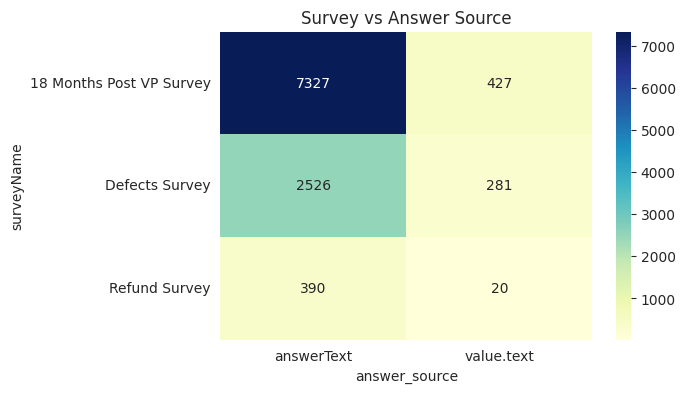

In [ ]:
ct1 = pd.crosstab(df["surveyName"], df["answer_source"])

plt.figure(figsize=(6,4))
sns.heatmap(ct1, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Survey vs Answer Source")
plt.show()

**Combine language, question group, question, and answer into a single structured text input for model training and better contextual understanding**

In [ ]:
df["final_text"] = (
    "[LANG] " + df["language_clean"].astype(str) +
    " [QGROUP] " + df["question_group"].astype(str) +
    " [QUESTION] " + df["questionText_clean"].astype(str) +
    " [ANSWER] " + df["final_answer_for_model"].astype(str)
)

df[["language_clean", "question_group", "final_text"]].head()

,language_clean,question_group,final_text
0,chinese (simplified),structured_sentiment,[LANG] chinese (simplified) [QGROUP] structured_sentiment [QUESTION] How satisfied are you with the customer support provided for the Novade application? [ANSWER] Satisfied
3,chinese (simplified),rating_intent,[LANG] chinese (simplified) [QGROUP] rating_intent [QUESTION] How likely would you recommend Mah Sings product to a friend or colleague? [ANSWER] 8
4,chinese (simplified),structured_sentiment,[LANG] chinese (simplified) [QGROUP] structured_sentiment [QUESTION] How easy is it to use the Novade application? [ANSWER] Easy
10,english,other,[LANG] english [QGROUP] other [QUESTION] The Customer Service Representative made me feel cared for [ANSWER] Agree
11,english,other,[LANG] english [QGROUP] other [QUESTION] The Customer Service Representative was polite and friendly [ANSWER] Agree


**Sentiment Labelling**

In [ ]:
def get_sentiment(x):
    x = str(x).lower()

    if x.isdigit():
        x = int(x)
        if x <= 6:
            return "Negative"
        elif x <= 8:
            return "Neutral"
        else:
            return "Positive"

    if x in ["very positive", "positive", "very easy", "easy",
             "extremely satisfied", "satisfied", "strongly agree", "agree", "yes", "likely", "very likely"]:
        return "Positive"

    if "neither" in x:
        return "Neutral"

    if x in ["negative", "very negative", "difficult", "very difficult",
             "dissatisfied", "extremely dissatisfied", "disagree", "strongly disagree", "unlikely", "very unlikely", "no"]:
        return "Negative"

    return None

**Count On Sentiment Labels**

In [ ]:
df["sentiment"] = df["final_answer_for_model"].apply(get_sentiment)

df["sentiment"].value_counts()

,count
sentiment,
Positive,6381
Neutral,2226
Negative,1186


In [ ]:
df_model = df[df["sentiment"].notna()].copy()

In [ ]:
label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}

df_model["label"] = df_model["sentiment"].map(label_map)

In [ ]:
model_prep = df_model[[
    "responseID",
    "surveyName",
    "language_clean",
    "question_group",
    "question_family",
    "final_text",
    "sentiment",
    "label"
]].copy()

print(model_prep.shape)
model_prep.head()

(9793, 8)


,responseID,surveyName,language_clean,question_group,question_family,final_text,sentiment,label
0,142316144,Defects Survey,chinese (simplified),structured_sentiment,satisfaction,[LANG] chinese (simplified) [QGROUP] structured_sentiment [QUESTION] How satisfied are you with the customer support provided for the Novade application? [ANSWER] Satisfied,Positive,2
3,142316144,Defects Survey,chinese (simplified),rating_intent,nps,[LANG] chinese (simplified) [QGROUP] rating_intent [QUESTION] How likely would you recommend Mah Sings product to a friend or colleague? [ANSWER] 8,Neutral,1
4,142316144,Defects Survey,chinese (simplified),structured_sentiment,ease,[LANG] chinese (simplified) [QGROUP] structured_sentiment [QUESTION] How easy is it to use the Novade application? [ANSWER] Easy,Positive,2
10,142317923,Defects Survey,english,other,other,[LANG] english [QGROUP] other [QUESTION] The Customer Service Representative made me feel cared for [ANSWER] Agree,Positive,2
11,142317923,Defects Survey,english,other,agreement,[LANG] english [QGROUP] other [QUESTION] The Customer Service Representative was polite and friendly [ANSWER] Agree,Positive,2


**Define x and y for model training **

In [ ]:
X = df_model["final_text"]
y = df_model["label"]

**Train and Test Split**

In [ ]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain %:", round(len(train_df)/len(model_prep)*100, 2), "%")
print("Test %:", round(len(test_df)/len(model_prep)*100, 2), "%")

Train shape: (7698, 39)
Test shape: (2095, 39)

Train %: 78.61 %
Test %: 21.39 %


**Unique Customer in Train and Test Split**

In [ ]:
print("\nUnique customers in Train:", train_df["responseID"].nunique())
print("Unique customers in Test:", test_df["responseID"].nunique())

overlap = set(train_df["responseID"]).intersection(set(test_df["responseID"]))
print("Overlap customers:", len(overlap))


Unique customers in Train: 544
Unique customers in Test: 136
Overlap customers: 0


**Saved The splitting file**

In [ ]:
train_df.to_csv("train_dataset.csv", index=False)
test_df.to_csv("test_dataset.csv", index=False)

print("Files saved successfully!")

Files saved successfully!


**Group Shuffle Split on Response ID**

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(model_prep, groups=model_prep["responseID"]))

train_df = model_prep.iloc[train_idx].copy()
test_df = model_prep.iloc[test_idx].copy()

X_train = train_df["final_text"]
X_test = test_df["final_text"]
y_train = train_df["label"]
y_test = test_df["label"]

**TF-IDF Vectorization**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

**Model Training**

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train_vec, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

**Prediction and Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_train_pred = model.predict(X_train_vec)
y_test_pred = model.predict(X_test_vec)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Accuracy Difference:", train_acc - test_acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

Train Accuracy: 0.9696024941543258
Test Accuracy: 0.9646778042959427
Accuracy Difference: 0.004924689858383013

Classification Report:

              precision    recall  f1-score   support

           0       0.76      1.00      0.86       231
           1       1.00      0.88      0.94       512
           2       1.00      0.99      1.00      1352

    accuracy                           0.96      2095
   macro avg       0.92      0.96      0.93      2095
weighted avg       0.97      0.96      0.97      2095



**Save Model**

In [ ]:
import joblib

# Save model
joblib.dump(model, "sentiment_model.pkl_1")

# Save vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl_1")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


**Confusion Matrix**

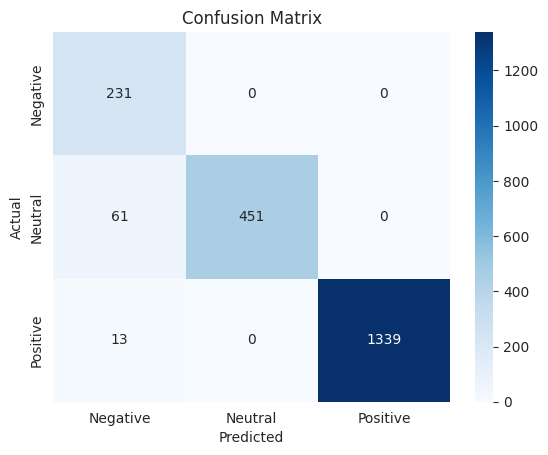

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Top Features for Sentiment Analysis**

In [ ]:
feature_names = vectorizer.get_feature_names_out()

for class_id, class_name in enumerate(["Negative", "Neutral", "Positive"]):
    top_idx = model.coef_[class_id].argsort()[-15:]
    print(f"\nTop features for {class_name}:")
    print(feature_names[top_idx])


Top features for Negative:
['negative' 'difficult' 'answer negative' 'answer difficult'
 'answer unlikely' 'answer no' 'no' 'very unlikely' 'unlikely'
 'strongly disagree' 'disagree' 'extremely dissatisfied' 'answer disagree'
 'dissatisfied' 'answer dissatisfied']

Top features for Neutral:
['nor difficult' 'dissatisfied' 'disagree' 'likely nor' 'neither likely'
 'nor unlikely' 'agree nor' 'neither agree' 'nor disagree'
 'neither satisfied' 'satisfied nor' 'nor dissatisfied' 'answer neither'
 'nor' 'neither']

Top features for Positive:
['positive' 'answer positive' 'answer easy' 'answer yes' 'yes'
 'very likely' 'answer likely' 'strongly agree' 'extremely satisfied'
 'agree' 'answer agree' 'satisfied' '10' 'answer 10' 'answer satisfied']


In [ ]:
def predict_sentiment(question, answer, language="unknown"):
    answer_clean = normalize_text(answer)
    translated = translate_text(answer_clean)

    final_input = (
        "[LANG] " + str(language).lower().strip() +
        " [QGROUP] unknown" +
        " [QUESTION] " + str(question) +
        " [ANSWER] " + str(translated)
    )

    vec = vectorizer.transform([final_input])

    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]

    inv_label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

    return {
        "prediction": inv_label_map[pred],
        "translated_answer": translated,
        "probabilities": {
            "Negative": prob[0],
            "Neutral": prob[1],
            "Positive": prob[2]
        }
    }

**Prediction on Test Data**

In [ ]:
result = predict_sentiment(
    question="What can Mah Sing do to improve your satisfaction with our Customer Service Representatives?",
    answer="聘请多点各种族的人 了解沟通比较容易",
    language="chinese"
)

print(result)

{'prediction': 'Negative', 'translated_answer': 'Hire more people of various races to understand and communicate more easily', 'probabilities': {'Negative': np.float64(0.7393736102294112), 'Neutral': np.float64(0.06488129409954828), 'Positive': np.float64(0.19574509567104043)}}


**Trained DistilBert on Question+Answers combination but the model found very easy patterns to learn **

In [ ]:
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import GroupShuffleSplit
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
import evaluate

In [ ]:
df_model = df[df["sentiment"].notna()].copy()

label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
id2label = {0: "Negative", 1: "Neutral", 2: "Positive"}

df_model["label"] = df_model["sentiment"].map(label_map)

print(df_model.shape)
df_model[["final_text", "sentiment", "label"]].head()

(9793, 39)


,final_text,sentiment,label
0,[LANG] chinese (simplified) [QGROUP] structured_sentiment [QUESTION] How satisfied are you with the customer support provided for the Novade application? [ANSWER] Satisfied,Positive,2
3,[LANG] chinese (simplified) [QGROUP] rating_intent [QUESTION] How likely would you recommend Mah Sings product to a friend or colleague? [ANSWER] 8,Neutral,1
4,[LANG] chinese (simplified) [QGROUP] structured_sentiment [QUESTION] How easy is it to use the Novade application? [ANSWER] Easy,Positive,2
10,[LANG] english [QGROUP] other [QUESTION] The Customer Service Representative made me feel cared for [ANSWER] Agree,Positive,2
11,[LANG] english [QGROUP] other [QUESTION] The Customer Service Representative was polite and friendly [ANSWER] Agree,Positive,2


In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(df_model, groups=df_model["responseID"]))

train_df = df_model.iloc[train_idx].copy()
test_df = df_model.iloc[test_idx].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Overlap responseIDs:", len(set(train_df["responseID"]).intersection(set(test_df["responseID"]))))

Train shape: (7698, 39)
Test shape: (2095, 39)
Overlap responseIDs: 0


In [ ]:
train_hf = Dataset.from_pandas(train_df[["final_text", "label"]].reset_index(drop=True))
test_hf = Dataset.from_pandas(test_df[["final_text", "label"]].reset_index(drop=True))

In [ ]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize_function(example):
    return tokenizer(
        example["final_text"],
        truncation=True,
        max_length=128
    )

train_hf = train_hf.map(tokenize_function, batched=True)
test_hf = test_hf.map(tokenize_function, batched=True)

Map:   0%|          | 0/7698 [00:00<?, ? examples/s]

Map:   0%|          | 0/2095 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label_map
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_metric.compute(predictions=preds, references=labels)
    f1 = f1_metric.compute(predictions=preds, references=labels, average="weighted")
    precision = precision_metric.compute(predictions=preds, references=labels, average="weighted")
    recall = recall_metric.compute(predictions=preds, references=labels, average="weighted")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": precision["precision"],
        "recall": recall["recall"],
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./bert_sentiment_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available()
)

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=test_hf,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.078398,0.002579,0.999523,0.999522,0.999523,0.999523
2,0.001726,0.000283,1.000000,1.000000,1.000000,1.000000
3,0.000385,0.000216,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1446, training_loss=0.02683638965770252, metrics={'train_runtime': 90.7001, 'train_samples_per_second': 254.619, 'train_steps_per_second': 15.943, 'total_flos': 239280750289656.0, 'train_loss': 0.02683638965770252, 'epoch': 3.0})

In [ ]:
open_df = df[df["is_open_text"] == True].copy()

print("Open-text rows:", open_df.shape)
open_df[["questionText_clean", "final_answer_clean"]].head()

Open-text rows: (1115, 38)


,questionText_clean,final_answer_clean
37,What can Mah Sing do to improve your satisfaction with the defect rectifications?,很多间房屋的厕所漏水 多注意
64,What can Mah Sing do to improve your satisfaction with the defect rectifications?,Speed
91,What can Mah Sing do to improve your satisfaction with our Customer Service Representatives?,聘请多点各种族的人 了解沟通比较容易
97,What can Mah Sing do to improve your satisfaction with the defect rectifications?,效率
104,What can Mah Sing do to improve your satisfaction with customer support for the Novade application?,上传照片的清晰度


In [ ]:
open_df["bert_input"] = (
    open_df["questionText_clean"].astype(str) + " [SEP] " +
    open_df["final_answer_clean"].astype(str)
)

open_df[["bert_input"]].head()

,bert_input
37,What can Mah Sing do to improve your satisfaction with the defect rectifications? [SEP] 很多间房屋的厕所漏水 多注意
64,What can Mah Sing do to improve your satisfaction with the defect rectifications? [SEP] Speed
91,What can Mah Sing do to improve your satisfaction with our Customer Service Representatives? [SEP] 聘请多点各种族的人 了解沟通比较容易
97,What can Mah Sing do to improve your satisfaction with the defect rectifications? [SEP] 效率
104,What can Mah Sing do to improve your satisfaction with customer support for the Novade application? [SEP] 上传照片的清晰度


**Trained Transformers model for only open-text**

In [ ]:
!pip install -q transformers datasets accelerate evaluate sentencepiece

In [ ]:
from transformers import pipeline

pseudo_pipe = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment"
)

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
def auto_label_open_text(text):
    result = pseudo_pipe(text[:512])[0]
    label = result["label"].lower()

    if "negative" in label:
        return "Negative"
    elif "neutral" in label:
        return "Neutral"
    else:
        return "Positive"

In [ ]:
open_df["pseudo_sentiment"] = open_df["bert_input"].apply(auto_label_open_text)

open_df["pseudo_sentiment"].value_counts()

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,count
pseudo_sentiment,
Neutral,940
Negative,124
Positive,51


In [ ]:
label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
id2label = {0: "Negative", 1: "Neutral", 2: "Positive"}

open_df["label"] = open_df["pseudo_sentiment"].map(label_map)

open_df[["bert_input", "pseudo_sentiment", "label"]].head()

,bert_input,pseudo_sentiment,label
37,What can Mah Sing do to improve your satisfaction with the defect rectifications? [SEP] 很多间房屋的厕所漏水 多注意,Neutral,1
64,What can Mah Sing do to improve your satisfaction with the defect rectifications? [SEP] Speed,Neutral,1
91,What can Mah Sing do to improve your satisfaction with our Customer Service Representatives? [SEP] 聘请多点各种族的人 了解沟通比较容易,Neutral,1
97,What can Mah Sing do to improve your satisfaction with the defect rectifications? [SEP] 效率,Neutral,1
104,What can Mah Sing do to improve your satisfaction with customer support for the Novade application? [SEP] 上传照片的清晰度,Neutral,1


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(open_df, groups=open_df["responseID"]))

bert_train_df = open_df.iloc[train_idx].copy()
bert_test_df = open_df.iloc[test_idx].copy()

print("Train shape:", bert_train_df.shape)
print("Test shape:", bert_test_df.shape)
print("Train customers:", bert_train_df["responseID"].nunique())
print("Test customers:", bert_test_df["responseID"].nunique())
print("Overlap:", len(set(bert_train_df["responseID"]).intersection(set(bert_test_df["responseID"]))))

Train shape: (886, 41)
Test shape: (229, 41)
Train customers: 300
Test customers: 76
Overlap: 0


In [ ]:
# Create folders
import os

os.makedirs("bert_data/train", exist_ok=True)
os.makedirs("bert_data/test", exist_ok=True)

# Save files
bert_train_df.to_csv("bert_data/train/train.csv", index=False)
bert_test_df.to_csv("bert_data/test/test.csv", index=False)

print("Saved train and test datasets")

Saved train and test datasets


In [ ]:
from datasets import Dataset

train_hf = Dataset.from_pandas(
    bert_train_df[["bert_input", "label"]].reset_index(drop=True)
)
test_hf = Dataset.from_pandas(
    bert_test_df[["bert_input", "label"]].reset_index(drop=True)
)

In [ ]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
def tokenize_function(batch):
    return tokenizer(
        batch["bert_input"],
        truncation=True,
        padding=False,
        max_length=128
    )

train_hf = train_hf.map(tokenize_function, batched=True)
test_hf = test_hf.map(tokenize_function, batched=True)

Map:   0%|          | 0/886 [00:00<?, ? examples/s]

Map:   0%|          | 0/229 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label_map
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import numpy as np
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

In [ ]:
import numpy as np
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

In [ ]:
import torch
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_open_text_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available()
)

In [ ]:
from transformers import Trainer, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=test_hf,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.533828,0.311438,0.877729,0.839710,0.871317,0.877729
2,0.340884,0.279773,0.895197,0.877042,0.869904,0.895197
3,0.284197,0.284546,0.890830,0.874964,0.864679,0.890830


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=168, training_loss=0.38630302747090656, metrics={'train_runtime': 26.6695, 'train_samples_per_second': 99.664, 'train_steps_per_second': 6.299, 'total_flos': 58271688510444.0, 'train_loss': 0.38630302747090656, 'epoch': 3.0})

In [ ]:
bert_eval = trainer.evaluate()
print(bert_eval)

{'eval_loss': 0.2797670066356659, 'eval_accuracy': 0.8951965065502183, 'eval_f1': 0.8770418972206462, 'eval_precision': 0.8699040176861367, 'eval_recall': 0.8951965065502183, 'eval_runtime': 0.3053, 'eval_samples_per_second': 749.965, 'eval_steps_per_second': 49.124, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

train_preds_output = trainer.predict(train_hf)
test_preds_output = trainer.predict(test_hf)

train_preds = np.argmax(train_preds_output.predictions, axis=1)
test_preds = np.argmax(test_preds_output.predictions, axis=1)

bert_train_acc = accuracy_score(bert_train_df["label"], train_preds)
bert_test_acc = accuracy_score(bert_test_df["label"], test_preds)

print("BERT Train Accuracy:", bert_train_acc)
print("BERT Test Accuracy:", bert_test_acc)
print("Difference:", bert_train_acc - bert_test_acc)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


BERT Train Accuracy: 0.9006772009029346
BERT Test Accuracy: 0.8951965065502183
Difference: 0.005480694352716253


In [ ]:
print(
    classification_report(
        bert_test_df["label"],
        test_preds,
        target_names=["Negative", "Neutral", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.79      0.50      0.61        30
     Neutral       0.90      0.98      0.94       194
    Positive       0.00      0.00      0.00         5

    accuracy                           0.90       229
   macro avg       0.56      0.49      0.52       229
weighted avg       0.87      0.90      0.88       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
